# Um projeto de análise e previsão da resistência do concreto usando o dataset 'Concrete Compressive Strength' da UCI Machine Learning Repository. O objetivo é aplicar técnicas de ciência de dados e machine learning para prever a resistência à compressão com base na composição e idade do concreto.

---



In [2]:
pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
concrete_compressive_strength = fetch_ucirepo(id=165)

In [4]:
# data (as pandas dataframes)
X = concrete_compressive_strength.data.features
y = concrete_compressive_strength.data.targets


In [5]:
# metadata
print(concrete_compressive_strength.metadata)

{'uci_id': 165, 'name': 'Concrete Compressive Strength', 'repository_url': 'https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength', 'data_url': 'https://archive.ics.uci.edu/static/public/165/data.csv', 'abstract': 'Concrete is the most important material in civil engineering. The concrete compressive strength is a highly nonlinear function of age and ingredients. ', 'area': 'Physics and Chemistry', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 1030, 'num_features': 8, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Concrete compressive strength'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sun Feb 11 2024', 'dataset_doi': '10.24432/C5PK67', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 383, 'type': 'NATIVE', 'title': 'Modeling of strength of high-performance concrete using artificial neural networks', 'authors': 'I. Yeh', 'venue': 'C

### Análise Exploratória (EDA)
Uma análise inicial dos dados para entender o comportamento das variáveis:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Cement                         1030 non-null   float64
 1   Blast Furnace Slag             1030 non-null   float64
 2   Fly Ash                        1030 non-null   float64
 3   Water                          1030 non-null   float64
 4   Superplasticizer               1030 non-null   float64
 5   Coarse Aggregate               1030 non-null   float64
 6   Fine Aggregate                 1030 non-null   float64
 7   Age                            1030 non-null   int64  
 8   Concrete compressive strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB
None
            Cement  Blast Furnace Slag      Fly Ash        Water  \
count  1030.000000         1030.000000  1030.000000  1030.000000   
mean    281.167864           73.895825    

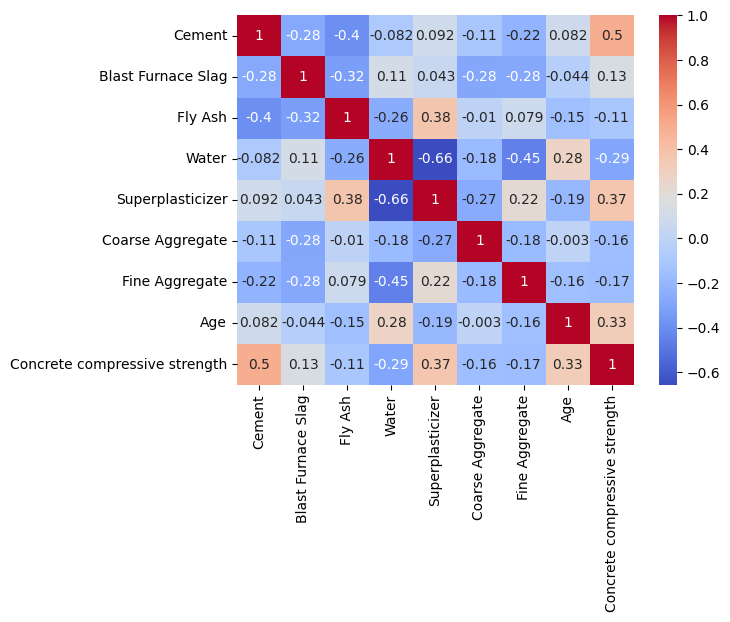

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.concat([X, y], axis=1)
print(df.info())
print(df.describe())

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()


## Preparando os dados
Dividindo em treino e teste!

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Modelagem Preditiva
Começando com um modelo de Regressão Linear


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R²:', r2_score(y_test, y_pred))


MAE: 7.745559243921434
RMSE: 9.796475901624358
R²: 0.627553179231485


A linha de predição no gráfico é aplicada apenas aos dados de teste (y_pred foi calculado usando X_test), não ao conjunto de dados completo. O modelo é treinado nos dados de treino (X_train, y_train), mas as previsões (y_pred) são feitas para os dados de teste (X_test). O gráfico compara essas previsões com os valores reais correspondentes nos dados de teste (y_test).

Portanto, o gráfico mostra o desempenho do modelo em dados que ele não viu durante o treinamento:


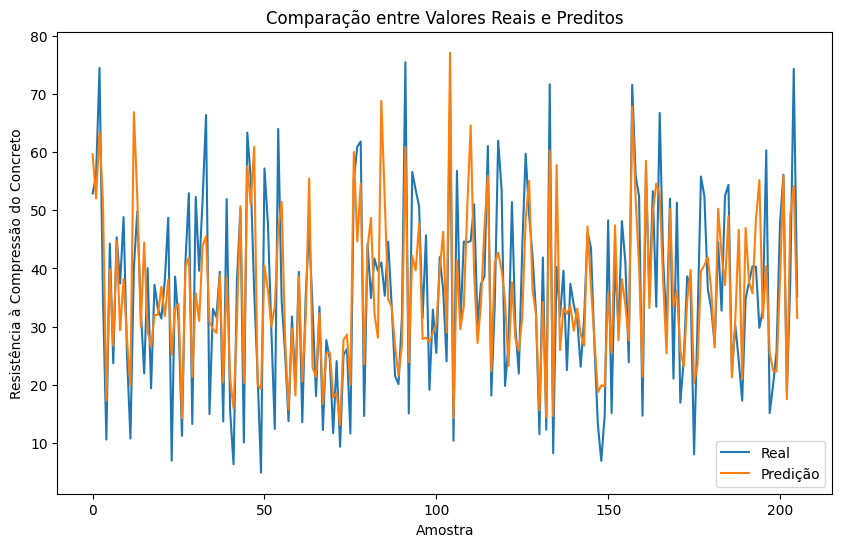

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Real')
plt.plot(y_pred, label='Predição')
plt.title('Comparação entre Valores Reais e Preditos')
plt.xlabel('Amostra')
plt.ylabel('Resistência à Compressão do Concreto')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


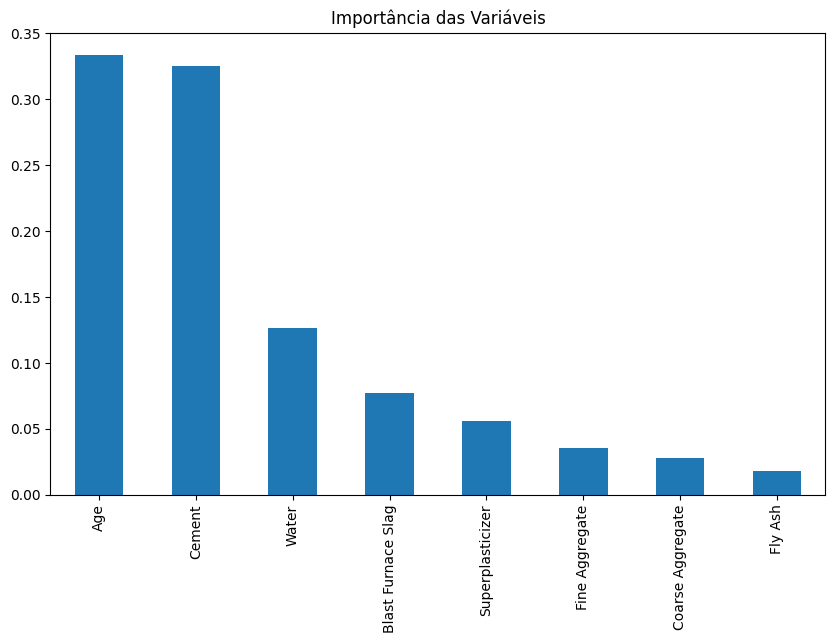

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(10,6))
plt.title('Importância das Variáveis')
plt.show()
